In [ ]:
%pip install -U "typing_extensions>=4.12.2" "pydantic>=2.7" 
%pip install -U langchain-community langchain langchain-openai langchain-text-splitters langgraph

In [ ]:
%pip install --upgrade pip wheel setuptools
%pip install --only-binary=all --no-build-isolation greenlet==3.0.3
%pip install --only-binary=all sqlalchemy==2.0.31 langchain-community langchain langchain-openai langgraph faiss-cpu tavily-python


In [2]:

from typing import List, TypedDict, Literal

from pathlib import Path


from pydantic import BaseModel, Field

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langchain_community.tools.tavily_search import TavilySearchResults


from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

True

In [ ]:
%pip install pypdf

In [3]:
doc_dir = Path("./documents")
pdf_paths = sorted(doc_dir.glob("*.pdf"))

docs = []
for pdf_path in pdf_paths:
    docs.extend(PyPDFLoader(str(pdf_path)).load())

len(docs)

327

In [4]:
chunks = RecursiveCharacterTextSplitter(
    chunk_size=600, chunk_overlap=150
).split_documents(docs)

In [5]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k": 4})

In [6]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [7]:
class State(TypedDict):
    question: str
    need_retrieval: bool

    docs: List[Document]
    relevant_docs: List[Document]

    context: str
    answer: str

    iteration: int 

    # web query (no loop flags)
    web_query: str

In [8]:
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)


# IMPORTANT: no `.content` for structured output
should_retrieve_llm = llm.with_structured_output(RetrieveDecision)

def decide_retrieval(state: "State"):
    decision: RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state["question"])
    )
    return {"need_retrieval": decision.should_retrieve}

In [9]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)


def generate_direct(state: State):
    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question=state["question"]
        )
    )
    return {
        "answer": out.content
    }

In [10]:
def retrieve(state: State):
    return {"docs": retriever.invoke(state["question"])}

In [11]:
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True if the document helps answer the question, else False."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance.\n"
            "Return JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        ),
    ]
)

relevance_llm = llm.with_structured_output(RelevanceDecision)

def is_relevant(state: State):
    
    relevant_docs: List[Document] = []

    for doc in state["docs"]:
        decision: RelevanceDecision = relevance_llm.invoke(
            is_relevant_prompt.format_messages(
                question=state["question"],
                document=doc.page_content
            )
        )

        if decision.is_relevant:
            relevant_docs.append(doc)

    return {"relevant_docs": relevant_docs, "iteration": state.get("iteration", 0) + 1}

In [12]:
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a aviation accident investigation assistant.\n"
            "Answer the user's question using ONLY the provided context.\n"
            "If the context does not contain enough information, say:\n"
            "'No relevant document found.'\n"
            "Do not use outside knowledge.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

def generate_from_context(state: State):
    # Stuff relevant docs into one block
    context = "\n\n---\n\n".join(
        [d.page_content for d in state.get("relevant_docs", [])]
    ).strip()

    if not context:
        return {"answer": "No relevant document found.", "context": ""}

    out = llm.invoke(
        rag_generation_prompt.format_messages(
            question=state["question"],
            context=context
        )
    )
    return {"answer": out.content, "context": context}

In [13]:
class WebQuery(BaseModel):
    query: str

rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user question into a web search query composed of keywords.\n"
            "Rules:\n"
            "- Keep it short (6–14 words).\n"
            "- If the question implies recency, add (last 30 days).\n"
            "- Do NOT answer the question.\n"
            "- Return JSON with a single key: query",
        ),
        ("human", "Question: {question}"),
    ]
)

rewrite_chain = rewrite_prompt | llm.with_structured_output(WebQuery)

def rewrite_query_node(state: State):
    out = rewrite_chain.invoke({"question": state["question"]})
    return {"web_query": out.query}

tavily = TavilySearchResults(max_results=5)

def web_search_node(state: State):
    q = state.get("web_query") or state["question"]
    results = tavily.invoke({"query": q})

    docs = []
    for r in results:
        if isinstance(r, str):
            content = r
        else:
            content = r.get("content", str(r))
        docs.append(Document(page_content=content))

    return {
        "docs": docs,
        "relevant_docs": [],
        "context": "",
        "answer": "",
    }

C:\Users\dharm\AppData\Local\Temp\ipykernel_31840\1438009174.py:25: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults(max_results=5)


In [14]:
def no_relevant_docs(state: State):
    return {"answer": "No relevant document found.", "context": ""}

In [15]:
def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    if state["need_retrieval"]:
        return "retrieve"
    return "generate_direct"

In [16]:
def route_after_relevance(state) -> Literal["generate_from_context", "rewrite_query", END]:
    iteration = state.get("iteration", 0)
    if iteration > 3:  # Stop after 3 loops
        return END
    if state.get("relevant_docs") and len(state["relevant_docs"]) > 0:
        return "generate_from_context"
    return "rewrite_query"


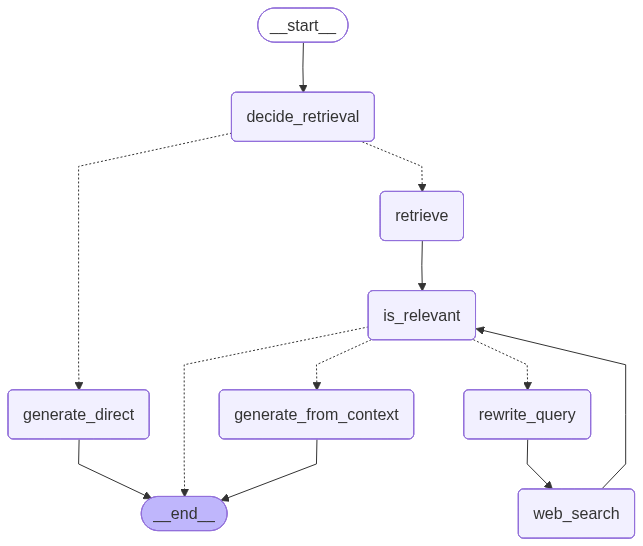

In [17]:
g = StateGraph(State)

g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)

g.add_node("is_relevant", is_relevant)
g.add_node("generate_from_context", generate_from_context)

# ✅ new nodes (replace no_relevant_docs)
g.add_node("rewrite_query", rewrite_query_node)
g.add_node("web_search", web_search_node)

# --------------------
# Edges
# --------------------
g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct": "generate_direct",
        "retrieve": "retrieve",
    },
)

g.add_edge("generate_direct", END)

# vector retrieval → relevance
g.add_edge("retrieve", "is_relevant")

# relevance router: if relevant → generate, else → rewrite_query
g.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {
        "generate_from_context": "generate_from_context",
        "rewrite_query": "rewrite_query",
        END: END,
    },
)

# web fallback path
g.add_edge("rewrite_query", "web_search")
g.add_edge("web_search", "is_relevant")  

# final
g.add_edge("generate_from_context", END)

app = g.compile()
app

In [18]:
result = app.invoke(
    {
        "question": "What was the probable cause of the VT-PTE accident?",
        "docs": [],
        "relevant_docs": [],
        "context": "",
        "answer": "",
    }, {"recursion_limit": 200}
)

for doc in result['relevant_docs']:
    print(doc.page_content)
    print("*"*100)

20 
 
 
FIG 3: LOCATION OF ACCIDENT SITE FROM REWA AIRFIELD. 
 
FIG 4: PICTORIAL REPRESENTATION OF VT-PTE FINAL PATH, IMPACT AND FINAL POSITION. 
 
The aircraft was subjected to extensive compression damage to the forward fuselage, after 
heavy impact with trees, concrete structure, and ground. Some of the major damages sustained 
by the aircraft are appended below: -  
• Both wings were found fully detached from the aircraft structure. 
• The aircraft empennage was found separated from the Aircraft.  
• The left horizontal stabilizer was observed with the banner tow cables and some tree
****************************************************************************************************
5 
 
SYNOPSIS 
On 05 January 2023, a Cessna 152 aircraft with registration number VT-PTE owned by M/s 
Falcon Aviation Academy was involved in a fatal accident during a Night Training sortie in 
Rewa, Madhya Pradesh. The accident occurred at around 18 20 UTC at Umari Village, 
approximately 0.86NM from 